As part of Lab 3, students are required to explore using a dataset of their choice. The selected dataset must contain and , including both .
Select or create a suitable dataset with numeric and nominal features.Perform basic data preprocessing:
* Handle missing values
* Encode categorical variables
* Apply feature scaling if required

Split the dataset into training and testing sets.

Build a Linear Regression model.Evaluate the model using:
* Mean Absolute Error (MAE)
* Mean Squared Error (MSE)
* Root Mean Squared Error (RMSE)
* R² Score

Analyze the concept of by comparing training and testing performance.Explain whether the model is generalized or overfitted.Suggest possible methods to reduce overfitting, such as:
* Feature selection
* Cross-validation
* Removing irrelevant variables

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import warnings
warnings.filterwarnings("ignore")

**Loading the dataset**

In [2]:
data = pd.read_csv("Housing.csv")

**Basic exploration**

In [3]:
print("Shape:", data.shape)

Shape: (5000, 7)


In [4]:
data.head()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price,Address
0,79545.458574,5.682861,7.009188,4.09,23086.800503,1.059034e+06,"208 Michael Ferry Apt. 674\nLaurabury, NE 3701..."
1,79248.642455,6.002900,6.730821,3.09,40173.072174,1.505891e+06,"188 Johnson Views Suite 079\nLake Kathleen, CA..."
2,61287.067179,5.865890,8.512727,5.13,36882.159400,1.058988e+06,"9127 Elizabeth Stravenue\nDanieltown, WI 06482..."
3,63345.240046,7.188236,5.586729,3.26,34310.242831,1.260617e+06,USS Barnett\nFPO AP 44820
4,59982.197226,5.040555,7.839388,4.23,26354.109472,6.309435e+05,USNS Raymond\nFPO AE 09386


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Avg. Area Income              5000 non-null   float64
 1   Avg. Area House Age           5000 non-null   float64
 2   Avg. Area Number of Rooms     5000 non-null   float64
 3   Avg. Area Number of Bedrooms  5000 non-null   float64
 4   Area Population               5000 non-null   float64
 5   Price                         5000 non-null   float64
 6   Address                       5000 non-null   object 
dtypes: float64(6), object(1)
memory usage: 273.6+ KB


In [6]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
Avg. Area Income,5000.0,6.858311e+04,10657.991214,17796.631190,61480.562388,6.880429e+04,7.578334e+04,1.077017e+05
Avg. Area House Age,5000.0,5.977222e+00,0.991456,2.644304,5.322283,5.970429e+00,6.650808e+00,9.519088e+00
Avg. Area Number of Rooms,5000.0,6.987792e+00,1.005833,3.236194,6.299250,7.002902e+00,7.665871e+00,1.075959e+01
Avg. Area Number of Bedrooms,5000.0,3.981330e+00,1.234137,2.000000,3.140000,4.050000e+00,4.490000e+00,6.500000e+00
Area Population,5000.0,3.616352e+04,9925.650114,172.610686,29403.928702,3.619941e+04,4.286129e+04,6.962171e+04
Price,5000.0,1.232073e+06,353117.626581,15938.657923,997577.135049,1.232669e+06,1.471210e+06,2.469066e+06


**Checking for null values**

In [7]:
data.isnull().sum()

Avg. Area Income                0
Avg. Area House Age             0
Avg. Area Number of Rooms       0
Avg. Area Number of Bedrooms    0
Area Population                 0
Price                           0
Address                         0
dtype: int64

**Checking for duplicate values**

In [8]:
print("Duplicates:", data.duplicated().sum())

Duplicates: 0


**Inspecting columns**

In [10]:
data.columns.tolist()

['Avg. Area Income',
 'Avg. Area House Age',
 'Avg. Area Number of Rooms',
 'Avg. Area Number of Bedrooms',
 'Area Population',
 'Price',
 'Address']

In [9]:
num_cols = data.select_dtypes(include=['int64', 'float64']).columns
cat_cols = data.select_dtypes(include=['object']).columns

print("Numerical Columns:")
print(num_cols)

print("\nCategorical Columns:")
print(cat_cols)

Numerical Columns:
Index(['Avg. Area Income', 'Avg. Area House Age', 'Avg. Area Number of Rooms',
       'Avg. Area Number of Bedrooms', 'Area Population', 'Price'],
      dtype='object')

Categorical Columns:
Index(['Address'], dtype='object')


**Removing unneccessary column - Address**

In [11]:
data.drop('Address', axis=1, inplace=True)

**Observing correlation between variables**

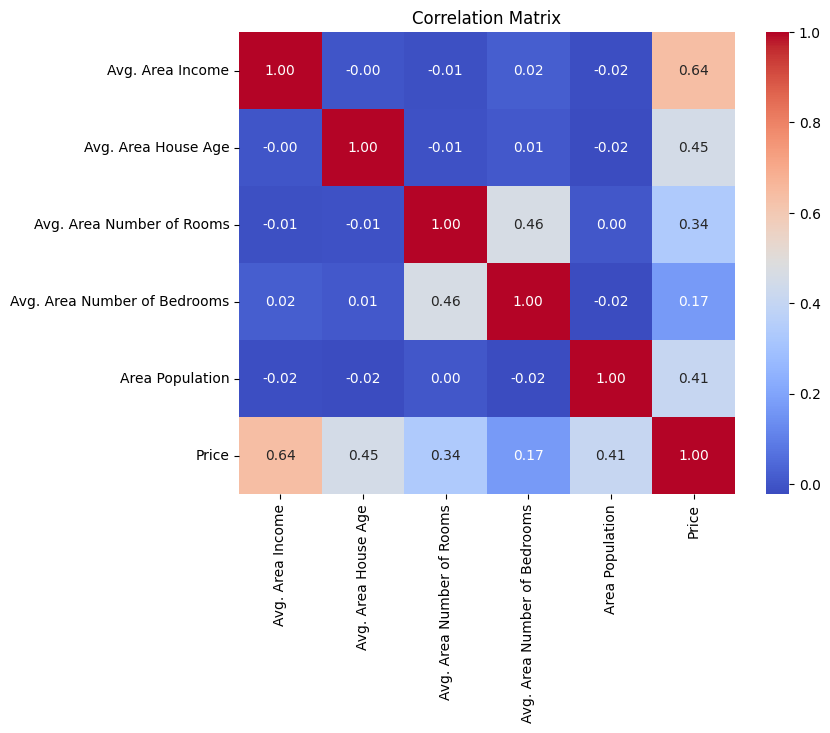

In [12]:
plt.figure(figsize=(8,6))

corr = data.corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

In [13]:
corr['Price'].sort_values(ascending=False)

Price                           1.000000
Avg. Area Income                0.639734
Avg. Area House Age             0.452543
Area Population                 0.408556
Avg. Area Number of Rooms       0.335664
Avg. Area Number of Bedrooms    0.171071
Name: Price, dtype: float64

**Simple linear regression between Avg Area Income and Price**

In [14]:
X = data[['Avg. Area Income']]
y = data['Price']

In [15]:
print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (5000, 1)
y Shape: (5000,)


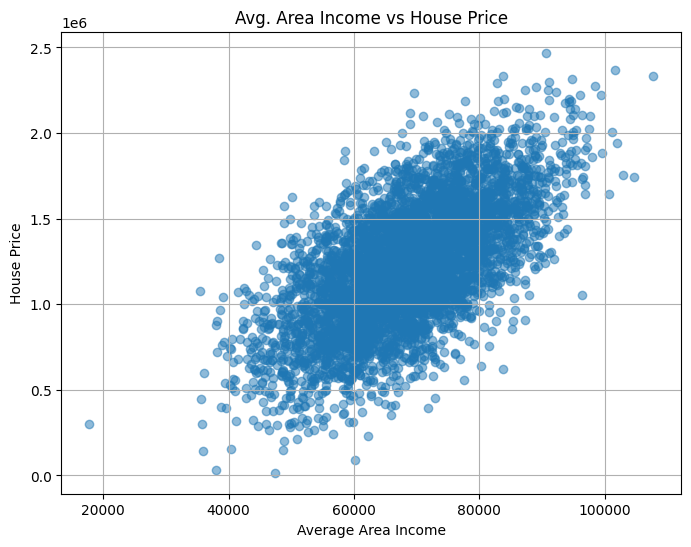

In [16]:
plt.figure(figsize=(8,6))

plt.scatter(
    data['Avg. Area Income'],
    data['Price'],
    alpha=0.5
)

plt.title("Avg. Area Income vs House Price")
plt.xlabel("Average Area Income")
plt.ylabel("House Price")

plt.grid(True)

plt.show()

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [18]:
print("Training Set:", X_train.shape)
print("Testing Set :", X_test.shape)

Training Set: (4000, 1)
Testing Set : (1000, 1)


In [19]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [20]:
model = LinearRegression()

model.fit(X_train_scaled, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [21]:
# Save learned parameters
income_price_slope = model.coef_[0]
income_price_intercept = model.intercept_

print("Slope     :", income_price_slope)
print("Intercept :", income_price_intercept)

Slope     : 226997.27684363606
Intercept : 1229576.9925600903


In [22]:
income_price_train_pred = model.predict(X_train_scaled)

In [23]:
income_price_test_pred = model.predict(X_test_scaled)

In [24]:
income_price_mae = mean_absolute_error(
    y_test,
    income_price_test_pred
)

income_price_mse = mean_squared_error(
    y_test,
    income_price_test_pred
)

income_price_rmse = np.sqrt(income_price_mse)

income_price_r2 = r2_score(
    y_test,
    income_price_test_pred
)

print("Model Evaluation")
print("----------------")
print("Slope      :", income_price_slope)
print("Intercept  :", income_price_intercept)
print()
print("MAE        :", income_price_mae)
print("MSE        :", income_price_mse)
print("RMSE       :", income_price_rmse)
print("R² Score   :", income_price_r2)

Model Evaluation
----------------
Slope      : 226997.27684363606
Intercept  : 1229576.9925600903

MAE        : 216826.35309989064
MSE        : 74194887058.66
RMSE       : 272387.38417676394
R² Score   : 0.39694865192619766


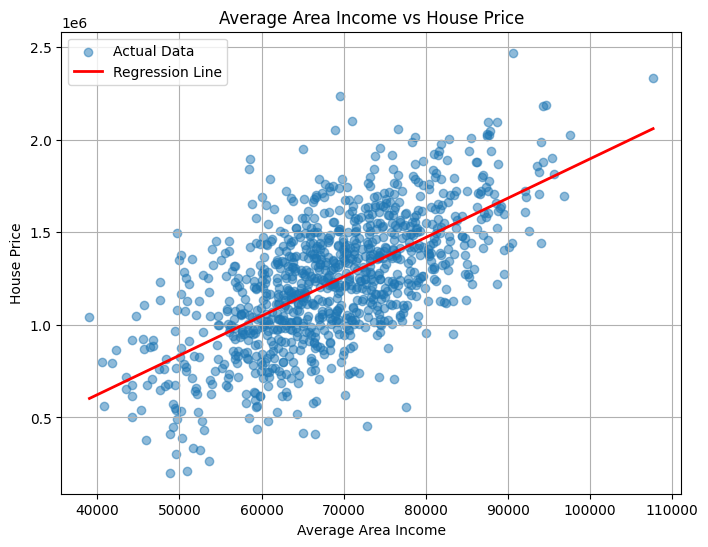

In [25]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_test,
    y_test,
    alpha=0.5,
    label="Actual Data"
)

# Sort values so the regression line is smooth
sorted_idx = np.argsort(X_test.values.flatten())

plt.plot(
    X_test.values.flatten()[sorted_idx],
    income_price_test_pred[sorted_idx],
    color='red',
    linewidth=2,
    label='Regression Line'
)

plt.title("Average Area Income vs House Price")
plt.xlabel("Average Area Income")
plt.ylabel("House Price")
plt.legend()
plt.grid(True)

plt.show()

**Muliple linear regression**

In [28]:
X = data.drop('Price', axis=1)
y = data['Price']

In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Set:", X_train.shape)
print("Testing Set :", X_test.shape)

Training Set: (4000, 5)
Testing Set : (1000, 5)


In [31]:

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [32]:
model = LinearRegression()

model.fit(X_train_scaled, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [33]:
# Save parameters
MLR_slope = model.coef_
MLR_intercept = model.intercept_

print("Intercept:")
print(MLR_intercept)

print("\nCoefficients:")
print(MLR_slope)

Intercept:
1229576.9925600903

Coefficients:
[231741.87665217 163580.77656614 120724.77138745   2992.44913541
 152235.90009699]


In [36]:
# Save parameters
MLR_slope = model.coef_
MLR_intercept = model.intercept_

print("Intercept:")
print(MLR_intercept)


Intercept:
1229576.9925600903


In [35]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coefficients

,Feature,Coefficient
0,Avg. Area Income,231741.876652
1,Avg. Area House Age,163580.776566
2,Avg. Area Number of Rooms,120724.771387
3,Avg. Area Number of Bedrooms,2992.449135
4,Area Population,152235.900097


In [37]:
MLR_y_train_pred = model.predict(X_train_scaled)

In [38]:
MLR_y_test_pred = model.predict(X_test_scaled)

In [39]:
MLR_mae = mean_absolute_error(y_test, MLR_y_test_pred)
MLR_mse = mean_squared_error(y_test, MLR_y_test_pred)
MLR_rmse = np.sqrt(MLR_mse)
MLR_r2 = r2_score(y_test, MLR_y_test_pred)

print("Multiple Linear Regression Results")
print("----------------------------------")
print(f"MAE      : {MLR_mae:.2f}")
print(f"MSE      : {MLR_mse:.2f}")
print(f"RMSE     : {MLR_rmse:.2f}")
print(f"R² Score : {MLR_r2:.4f}")

Multiple Linear Regression Results
----------------------------------
MAE      : 80879.10
MSE      : 10089009300.89
RMSE     : 100444.06
R² Score : 0.9180


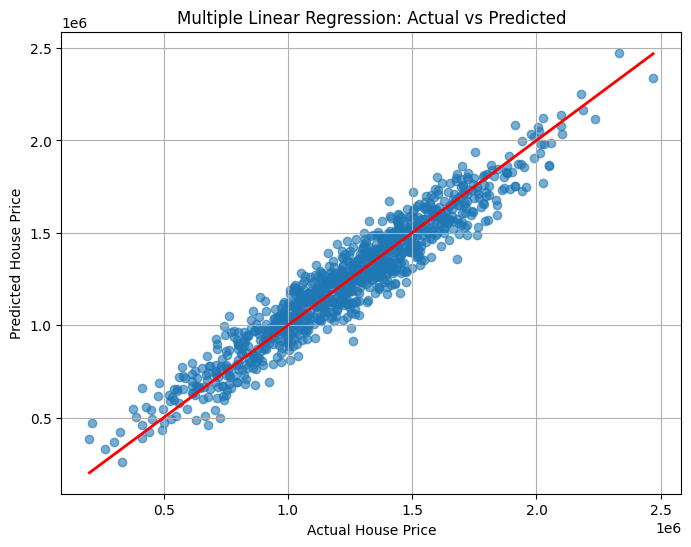

In [40]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    MLR_y_test_pred,
    alpha=0.6
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red',
    linewidth=2
)

plt.xlabel("Actual House Price")
plt.ylabel("Predicted House Price")
plt.title("Multiple Linear Regression: Actual vs Predicted")

plt.grid(True)

plt.show()